# Detección de Fraude Financiero — Proyecto de Métodos Numéricos para Machine Learning
### Versión final (Unidad 1: Optimización Numérica · Unidad 2: Álgebra Lineal Numérica)

**Dataset:** IEEE-CIS Fraud Detection · **Problema:** clasificación binaria fuertemente desbalanceada.

**Mapa del proyecto ↔ sílabo:**

| Bloque del notebook | Tema del sílabo |
|---|---|
| Regresión Logística (descenso de gradiente manual + solver SAGA) | **U1:** Gradiente Descendente / Optimización Convexa |
| XGBoost | **U1:** optimización del gradiente (gradient boosting) |
| Búsqueda del umbral óptimo `t*` | **U1:** optimización unidimensional |
| PCA vía SVD (autovalores, varianza explicada) | **U2:** Autovalores/Autovectores · SVD · PCA · Aplicaciones a ML |

> **Notas metodológicas clave:**
> 1. Las variables se **estandarizan** antes de los modelos basados en gradiente/distancia (Logística, KNN), para asegurar la convergencia del solver y que las distancias sean comparables.
> 2. El umbral `t*` se elige en un **conjunto de validación** separado del train, **no** en el test, evitando fuga de información.
> 3. Todos los estadísticos (mediana, frecuencias, cuantil de `HighAmount`) se calculan **solo con el train**.

## ETAPA 1 · Configuración, carga e ingeniería de características (sin fuga)

In [ ]:
import pandas as pd
import numpy as np
import gc, warnings
warnings.filterwarnings("ignore")

### 1.1 Montaje de Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.2 Carga de datos relacionales y merge (Left Join por TransactionID)

In [ ]:
path = "/content/drive/MyDrive/Archivos_CSV_Deteccion_Fraude"

train_transaction = pd.read_csv(path + "/train_transaction.csv")
train_identity    = pd.read_csv(path + "/train_identity.csv")
print(train_transaction.shape, train_identity.shape)

df = train_transaction.merge(train_identity, on="TransactionID", how="left")
del train_transaction, train_identity
gc.collect()
print("df:", df.shape)

(590540, 394) (144233, 41)
df: (590540, 434)


### 1.3 Distribución de la clase objetivo (desbalance)

In [ ]:
print(df["isFraud"].value_counts())
print("Tasa de fraude:", round(df["isFraud"].mean(), 4))

isFraud
0    569877
1     20663
Name: count, dtype: int64
Tasa de fraude: 0.035


### 1.4 Ingeniería de características *row-wise* (no usa estadísticos globales → no hay fuga)
`Hour`, `Day`, `Week` se derivan de `TransactionDT`; `LogAmt = ln(1+TransactionAmt)` estabiliza la varianza del monto; `NightTransaction` marca la franja 00:00–05:59.

In [ ]:
df["Hour"] = (df["TransactionDT"] // 3600) % 24
df["Day"]  = df["TransactionDT"] // 86400
df["Week"] = df["TransactionDT"] // (86400 * 7)
df["LogAmt"] = np.log1p(df["TransactionAmt"])
df["NightTransaction"] = (df["Hour"] < 6).astype("int8")

### 1.5 Filtro de columnas casi vacías (>90% nulos)
Se eliminan columnas con más de 90% de valores faltantes (criterio estructural sobre la tasa de nulidad).

In [ ]:
miss = df.isnull().mean()
drop_cols = miss[miss > 0.90].index
print("Columnas eliminadas:", len(drop_cols))
df.drop(columns=drop_cols, inplace=True)
gc.collect()
print("df:", df.shape)

Columnas eliminadas: 12
df: (590540, 427)


## ETAPA 2 · Partición temporal: train / validación / test

En fraude los patrones cambian con el tiempo, por eso se ordena por `TransactionDT` y se corta cronológicamente (evita *data leakage* del futuro hacia el pasado).

- **train** (64%): ajusta preprocesamiento y modelos.
- **validación** (16%): se usa **solo** para elegir el umbral `t*`.
- **test** (20%): muestra fuera de tiempo, intacta hasta la evaluación final.

In [ ]:
df.sort_values("TransactionDT", inplace=True)
n = len(df)
i_test = int(n * 0.8)
train_full = df.iloc[:i_test].copy()
test       = df.iloc[i_test:].copy()

i_val = int(len(train_full) * 0.8)
train = train_full.iloc[:i_val].copy()
val   = train_full.iloc[i_val:].copy()

del df, train_full; gc.collect()
print("train:", train.shape, "| val:", val.shape, "| test:", test.shape)
print("Fraude  train=%.4f  val=%.4f  test=%.4f" %
      (train.isFraud.mean(), val.isFraud.mean(), test.isFraud.mean()))

train: (377945, 427) | val: (94487, 427) | test: (118108, 427)
Fraude  train=0.0341  val=0.0392  test=0.0344


### 2.1 Creación de la característica HighAmount mediante cuantil 0.95

Se calcula el percentil 95% de la variable `TransactionAmt` para establecer un umbral estadístico que permita identificar transacciones con montos elevados.  
Las operaciones que superan este límite se clasifican como valores altos (`HighAmount = 1`), mientras que las demás se mantienen como valores normales (`HighAmount = 0`).

Este proceso transforma una variable continua en una característica binaria, incorporando información adicional que puede ayudar al modelo a detectar patrones asociados al fraude.

In [ ]:
q95 = train["TransactionAmt"].quantile(0.95)
for part in (train, val, test):
    part["HighAmount"] = (part["TransactionAmt"] > q95).astype("int8")
print("Cuantil 0.95 (train):", round(q95, 2))

Cuantil 0.95 (train): 442.0


## ETAPA 3 · Imputación, codificación y optimización de memoria
Todo se ajusta en train y se proyecta a val/test (sin fuga). Se usa *frequency encoding* para evitar la explosión de memoria del One-Hot ante alta cardinalidad.

In [ ]:
drop = ["TransactionID", "TransactionDT", "isFraud"]
y_train = train["isFraud"].values
y_val   = val["isFraud"].values
y_test  = test["isFraud"].values

features = [c for c in train.columns if c not in drop]
X_train, X_val, X_test = train[features].copy(), val[features].copy(), test[features].copy()
del train, val, test; gc.collect()

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()
print(f"Categóricas: {len(cat_cols)} | Numéricas: {len(num_cols)}")

# Imputación por mediana de TRAIN (sin chained-assignment)
medians = X_train[num_cols].median().fillna(0)
X_train[num_cols] = X_train[num_cols].fillna(medians)
X_val[num_cols]   = X_val[num_cols].fillna(medians)
X_test[num_cols]  = X_test[num_cols].fillna(medians)

# Frequency encoding ajustado en TRAIN
for col in cat_cols:
    freq = X_train[col].value_counts(dropna=False) / len(X_train)
    X_train[col] = X_train[col].map(freq).fillna(0.0)
    X_val[col]   = X_val[col].map(freq).fillna(0.0)
    X_test[col]  = X_test[col].map(freq).fillna(0.0)

X_train = X_train.astype("float32")
X_val   = X_val.astype("float32")
X_test  = X_test.astype("float32")
gc.collect()
print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

Categóricas: 29 | Numéricas: 396
X_train: (377945, 425) | X_val: (94487, 425) | X_test: (118108, 425)


## ETAPA 4 · UNIDAD 1 — Gradiente Descendente (implementación explícita)

La regresión logística minimiza la **entropía cruzada**, una función **convexa**:
$$ J(\mathbf{w},b) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y_i\log\sigma(z_i) + (1-y_i)\log(1-\sigma(z_i))\Big] + \lambda\|\mathbf{w}\|^2,\quad z_i=\mathbf{w}^\top \mathbf{x}_i + b $$

El **descenso de gradiente** actualiza los parámetros en dirección opuesta al gradiente:
$$ \mathbf{w} \leftarrow \mathbf{w} - \eta\,\nabla_{\mathbf{w}}J,\qquad \nabla_{\mathbf{w}}J = \frac{1}{m}X^\top(\sigma(X\mathbf{w}+b)-\mathbf{y}) + 2\lambda\mathbf{w} $$

Implementamos el método a mano sobre las variables **estandarizadas** (el escalado mejora el condicionamiento y la convergencia) y graficamos el costo por iteración.

Costo inicial = 0.6931  ->  costo final = 0.1039


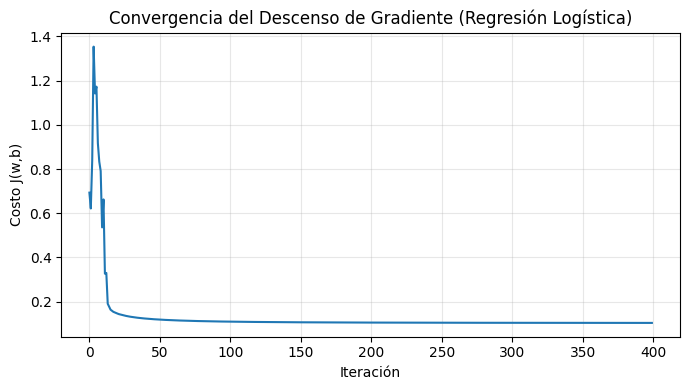

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler().fit(X_train)
Xtr_s = scaler.transform(X_train)

def logreg_gd(X, y, lr=0.5, epochs=400, lam=1e-3):
    m, d = X.shape
    w = np.zeros(d); b = 0.0; costs = []
    y = y.astype(float)
    for _ in range(epochs):
        h = 1 / (1 + np.exp(-(X @ w + b)))
        eps = 1e-9
        costs.append(-np.mean(y*np.log(h+eps) + (1-y)*np.log(1-h+eps)) + lam*np.sum(w**2))
        w -= lr * (X.T @ (h - y) / m + 2*lam*w)
        b -= lr * np.mean(h - y)
    return w, b, costs

w_gd, b_gd, costs = logreg_gd(Xtr_s, y_train, lr=0.5, epochs=400)
print(f"Costo inicial = {costs[0]:.4f}  ->  costo final = {costs[-1]:.4f}")

plt.figure(figsize=(7,4))
plt.plot(costs, color="#1f77b4")
plt.title("Convergencia del Descenso de Gradiente (Regresión Logística)")
plt.xlabel("Iteración"); plt.ylabel("Costo J(w,b)")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### 4.1 Efecto de la tasa de aprendizaje (η) en la convergencia
Comparamos el descenso de gradiente con distintos η. Un η pequeño converge lento;
uno grande converge rápido pero puede volverse inestable. Es la elección clásica de
todo método iterativo de optimización.

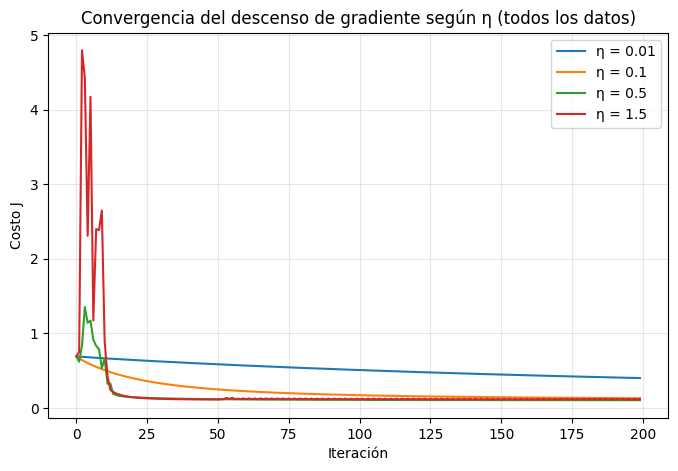

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
for lr in [0.01, 0.1, 0.5, 1.5]:
    _,_,costs_lr = logreg_gd(Xtr_s, y_train, lr=lr, epochs=200)   # TODOS los datos (378k filas)
    plt.plot(costs_lr, label=f"η = {lr}")
plt.xlabel("Iteración"); plt.ylabel("Costo J")
plt.title("Convergencia del descenso de gradiente según η (todos los datos)")
plt.legend(); plt.grid(alpha=.3); plt.show()

### Evaluación del modelo de Gradiente Descendente

Después de obtener los parámetros óptimos mediante el descenso de gradiente, se utilizan los pesos aprendidos (`w_gd`) y el sesgo (`b_gd`) para calcular la probabilidad de fraude sobre el conjunto de prueba.

Las probabilidades obtenidas se evalúan mediante la métrica AUC-ROC, permitiendo medir la capacidad del modelo para distinguir entre transacciones fraudulentas y legítimas.

Además, se verifica la reducción de la función de costo durante las iteraciones como evidencia de la convergencia del método numérico.

In [ ]:
from sklearn.metrics import roc_auc_score
Xte_s = scaler.transform(X_test)
prob_gd = 1/(1+np.exp(-(Xte_s @ w_gd + b_gd)))
print("Resultado del Gradiente Descendente manual")
print("  Costo:", round(costs[0],4), "→", round(costs[-1],4), "en", len(costs), "iteraciones")
print("  AUC en test:", round(roc_auc_score(y_test, prob_gd), 4))

Resultado del Gradiente Descendente manual
  Costo: 0.6931 → 0.1039 en 400 iteraciones
  AUC en test: 0.8151


## ETAPA 5 · UNIDAD 2 — PCA vía Descomposición en Valores Singulares (SVD)

PCA encuentra las direcciones de máxima varianza. Sobre la matriz estandarizada $X$, la SVD es $X = U\Sigma V^\top$; las columnas de $V$ son los **autovectores** de la matriz de covarianza y los $\sigma_i^2/(m-1)$ son sus **autovalores** (la varianza capturada por cada componente).

Autovalores (varianza) de las 5 primeras componentes: [47.1803 27.8628 21.6534 19.9506 17.4024]
Varianza explicada acumulada (20 comp.): 0.6096


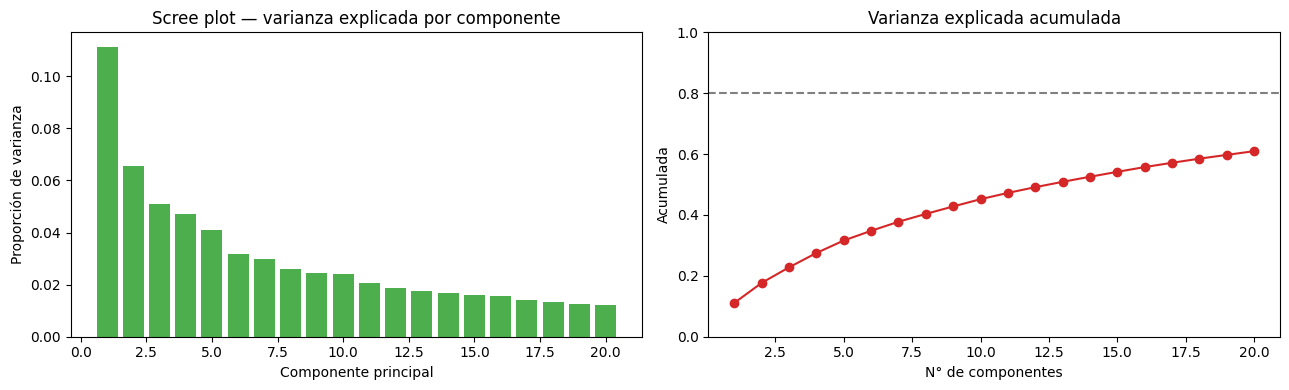

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20, svd_solver="randomized", random_state=42)
pca.fit(Xtr_s)
evr = pca.explained_variance_ratio_

print("Autovalores (varianza) de las 5 primeras componentes:", np.round(pca.explained_variance_[:5], 4))
print("Varianza explicada acumulada (20 comp.):", round(evr.sum(), 4))

fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].bar(range(1, 21), evr, color="#2ca02c", alpha=.85)
ax[0].set_title("Scree plot — varianza explicada por componente")
ax[0].set_xlabel("Componente principal"); ax[0].set_ylabel("Proporción de varianza")
ax[1].plot(range(1, 21), np.cumsum(evr), marker="o", color="#d62728")
ax[1].axhline(0.8, ls="--", color="gray"); ax[1].set_ylim(0, 1)
ax[1].set_title("Varianza explicada acumulada")
ax[1].set_xlabel("N° de componentes"); ax[1].set_ylabel("Acumulada")
plt.tight_layout(); plt.show()

### 5.1 Análisis de correlación previo a la reducción dimensional (PCA)

Antes de aplicar PCA se analiza la correlación entre variables numéricas para identificar posibles relaciones lineales y redundancia de información.

El mapa de calor permite visualizar qué variables contienen información similar, justificando posteriormente la aplicación de técnicas de reducción dimensional basadas en álgebra lineal para obtener una representación más compacta del conjunto de datos.

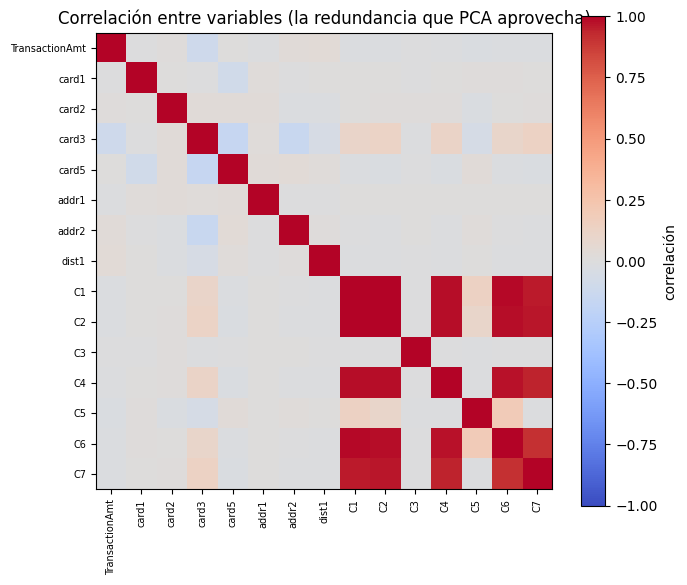

In [ ]:
import matplotlib.pyplot as plt
corr = X_train[num_cols[:15]].corr()
plt.figure(figsize=(7,6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1); plt.colorbar(im, label="correlación")
plt.xticks(range(15), num_cols[:15], rotation=90, fontsize=7)
plt.yticks(range(15), num_cols[:15], fontsize=7)
plt.title("Correlación entre variables (la redundancia que PCA aprovecha)")
plt.tight_layout(); plt.show()

### 5.2 Proyección del espacio de datos mediante PCA

Se utiliza el modelo PCA previamente ajustado para transformar las variables estandarizadas hacia un nuevo espacio definido por componentes principales.

La proyección sobre las dos primeras componentes (`PC1` y `PC2`) permite visualizar la distribución de las transacciones en un espacio reducido, conservando las direcciones de mayor variabilidad de los datos.

Esta transformación se basa en técnicas de álgebra lineal numérica, donde PCA obtiene nuevas bases mediante descomposición matricial y permite reducir la dimensionalidad manteniendo la información más relevante.

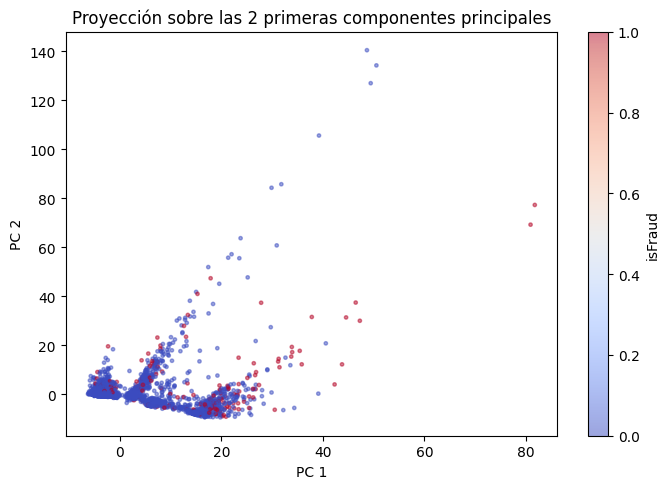

In [ ]:
Z = pca.transform(Xtr_s)[:, :2]
idx = np.random.RandomState(42).choice(len(Z), size=min(8000, len(Z)), replace=False)
plt.figure(figsize=(7,5))
plt.scatter(Z[idx,0], Z[idx,1], c=y_train[idx], cmap="coolwarm", s=6, alpha=.5)
plt.title("Proyección sobre las 2 primeras componentes principales")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.colorbar(label="isFraud")
plt.tight_layout(); plt.show()

### 5.2 Aplicación a ML: Regresión Logística sobre componentes PCA
Demostramos el uso de la reducción dimensional (U2) como entrada de un clasificador: se eligen las componentes que explican ~95% de la varianza.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

k = int(np.searchsorted(np.cumsum(PCA(svd_solver="randomized", random_state=42)
        .fit(Xtr_s).explained_variance_ratio_), 0.95)) + 1
k = max(k, 2)
print(f"Componentes para ~95% de varianza: {k}")

pca_ml = Pipeline([("sc", StandardScaler()),
                   ("pca", PCA(n_components=k, svd_solver="randomized", random_state=42)),
                   ("clf", LogisticRegression(max_iter=500, random_state=42))])
pca_ml.fit(X_train, y_train)
auc_pca = roc_auc_score(y_test, pca_ml.predict_proba(X_test)[:, 1])
print("AUC (Logística sobre PCA, test):", round(auc_pca, 4))

Componentes para ~95% de varianza: 141
AUC (Logística sobre PCA, test): 0.8164


## ETAPA 6 · Modelos base (con escalado donde corresponde)

Logística y KNN van dentro de un `Pipeline` con `StandardScaler` para que el gradiente (SAGA) converja y las distancias de KNN no queden dominadas por variables de gran escala. Umbral fijo `t=0.5`.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score)

def evaluar(y_true, prob, t=0.5):
    pred = (prob >= t).astype(int)
    return {"Precision": precision_score(y_true, pred, zero_division=0),
            "Recall":    recall_score(y_true, pred, zero_division=0),
            "F1":        f1_score(y_true, pred, zero_division=0),
            "MCC":       matthews_corrcoef(y_true, pred),
            "AUC":       roc_auc_score(y_true, prob)}

resultados = {}

print("1/4 Regresión Logística (SAGA, escalada)...")
lr = Pipeline([("sc", StandardScaler()),
               ("clf", LogisticRegression(solver="saga", max_iter=500,
                                          random_state=42, n_jobs=-1))]).fit(X_train, y_train)
resultados["Logística"] = evaluar(y_test, lr.predict_proba(X_test)[:, 1])
del lr; gc.collect()

print("2/4 KNN (escalado)...")
knn = Pipeline([("sc", StandardScaler()),
                ("clf", KNeighborsClassifier(n_neighbors=5, algorithm="ball_tree",
                                             leaf_size=40, n_jobs=-1))]).fit(X_train, y_train)
resultados["KNN"] = evaluar(y_test, knn.predict_proba(X_test)[:, 1])
del knn; gc.collect()

print("3/4 Árbol de decisión...")
dt = DecisionTreeClassifier(max_depth=12, random_state=42).fit(X_train, y_train)
resultados["Árbol"] = evaluar(y_test, dt.predict_proba(X_test)[:, 1])
del dt; gc.collect()

print("4/4 Random Forest base...")
rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42,
                            n_jobs=-1).fit(X_train, y_train)
resultados["RF base"] = evaluar(y_test, rf.predict_proba(X_test)[:, 1])
del rf; gc.collect()

import pandas as pd
print(pd.DataFrame(resultados).T.round(4))

1/4 Regresión Logística (SAGA, escalada)...
2/4 KNN (escalado)...
3/4 Árbol de decisión...
4/4 Random Forest base...
           Precision  Recall      F1     MCC     AUC
Logística     0.3552  0.2188  0.2707  0.2589  0.8119
KNN           0.6572  0.2382  0.3496  0.3839  0.7062
Árbol         0.5459  0.2852  0.3747  0.3797  0.7832
RF base       0.8291  0.2436  0.3766  0.4406  0.8546


## ETAPA 7 · SMOTE + optimización del umbral `t*` en VALIDACIÓN

Paso clave: el umbral que maximiza F1 se busca sobre **validación** y luego se aplica **una sola vez** al test, garantizando una evaluación sin fuga de información.

$$ t^* = \arg\max_{t\in[0.05,\,0.95]} F_1^{\text{val}}(t) $$

In [ ]:
  from imblearn.over_sampling import SMOTE
  from xgboost import XGBClassifier

  def mejor_umbral(y_true, prob):
      best_t, best = 0.5, -1
      for t in np.arange(0.05, 0.95, 0.01):
          s = f1_score(y_true, (prob >= t).astype(int), zero_division=0)
          if s > best: best, best_t = s, t
      return best_t

  print("Aplicando SMOTE (sampling_strategy=0.1) sobre TRAIN...")
  sm = SMOTE(sampling_strategy=0.1, random_state=42)
  X_sm, y_sm = sm.fit_resample(X_train, y_train)

  print("Random Forest de alta capacidad...")
  rf = RandomForestClassifier(n_estimators=300, max_depth=35, min_samples_split=5,
                              min_samples_leaf=2, random_state=42, n_jobs=-1).fit(X_sm, y_sm)
  t_rf = mejor_umbral(y_val, rf.predict_proba(X_val)[:, 1])      # umbral en VALIDACIÓN
  print(f"  t* (RF) elegido en validación = {t_rf:.2f}")
  resultados[f"RF+SMOTE (t*={t_rf:.2f})"] = evaluar(y_test, rf.predict_proba(X_test)[:, 1], t_rf)

  # Análisis de sensibilidad de umbrales (sobre test, solo para mostrar el trade-off)
  prob_rf_test = rf.predict_proba(X_test)[:, 1]
  sens = {}
  for t in [0.10, 0.20, 0.30, t_rf]:
      et = f"RF (t={t:.2f})" if t != t_rf else f"RF (t*={t_rf:.2f})"
      sens[et] = evaluar(y_test, prob_rf_test, t)
  del rf, X_sm, y_sm; gc.collect()

  print("XGBoost (gradient boosting)...")
  sm2 = SMOTE(sampling_strategy=0.1, random_state=42)
  X_sm, y_sm = sm2.fit_resample(X_train, y_train)
  xgb = XGBClassifier(n_estimators=200, max_depth=10, learning_rate=0.1,
                      tree_method="hist", random_state=42, n_jobs=-1).fit(X_sm, y_sm)
  t_xgb = mejor_umbral(y_val, xgb.predict_proba(X_val)[:, 1])    # umbral en VALIDACIÓN
  print(f"  t* (XGB) elegido en validación = {t_xgb:.2f}")
  resultados[f"XGBoost (t*={t_xgb:.2f})"] = evaluar(y_test, xgb.predict_proba(X_test)[:, 1], t_xgb)
  prob_xgb_test = xgb.predict_proba(X_test)[:, 1]
  del xgb, X_sm, y_sm; gc.collect()

  print("\n--- Sensibilidad de umbrales (Random Forest) ---")
  print(pd.DataFrame(sens).T.round(4))

Aplicando SMOTE (sampling_strategy=0.1) sobre TRAIN...
Random Forest de alta capacidad...
  t* (RF) elegido en validación = 0.30
XGBoost (gradient boosting)...
  t* (XGB) elegido en validación = 0.30

--- Sensibilidad de umbrales (Random Forest) ---
              Precision  Recall      F1     MCC     AUC
RF (t=0.10)      0.1689  0.7210  0.2737  0.3062  0.8793
RF (t=0.20)      0.2897  0.5224  0.3727  0.3602  0.8793
RF (t=0.30)      0.3815  0.4094  0.3950  0.3729  0.8793
RF (t*=0.30)     0.3815  0.4094  0.3950  0.3729  0.8793


### 7.1 Curva de optimización del umbral
Visualizamos cómo varían las métricas al recorrer el umbral t. El punto óptimo t*
es el que maximiza la métrica elegida (aquí marcamos el que maximiza MCC). Es la
representación gráfica de la búsqueda que hicimos antes en la tabla de sensibilidad.

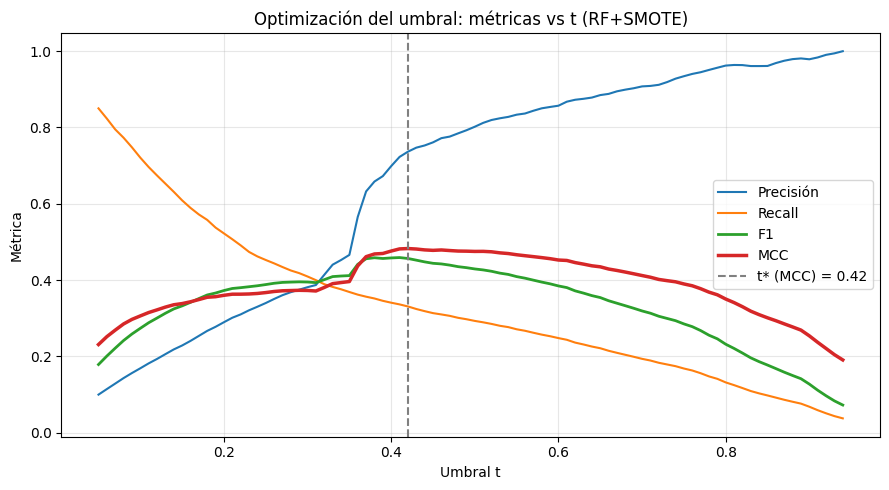

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
ts = np.arange(0.05, 0.95, 0.01)
P=[precision_score(y_test,(prob_rf_test>=t).astype(int),zero_division=0) for t in ts]
R=[recall_score(y_test,(prob_rf_test>=t).astype(int)) for t in ts]
F=[f1_score(y_test,(prob_rf_test>=t).astype(int),zero_division=0) for t in ts]
M=[matthews_corrcoef(y_test,(prob_rf_test>=t).astype(int)) for t in ts]
t_mcc = ts[int(np.argmax(M))]
plt.figure(figsize=(9,5))
plt.plot(ts,P,label="Precisión"); plt.plot(ts,R,label="Recall")
plt.plot(ts,F,label="F1",lw=2); plt.plot(ts,M,label="MCC",lw=2.5)
plt.axvline(t_mcc, ls="--", color="gray", label=f"t* (MCC) = {t_mcc:.2f}")
plt.xlabel("Umbral t"); plt.ylabel("Métrica")
plt.title("Optimización del umbral: métricas vs t (RF+SMOTE)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## ETAPA 8 · Resultados finales y comparación

Por el desbalance severo se priorizan **F1** y **MCC** (más exigentes que la exactitud).

In [ ]:
tabla = pd.DataFrame(resultados).T.round(4)
print("================= RESULTADOS FINALES (test intacto) =================")
print(tabla)

================= RESULTADOS FINALES (test intacto) =================
                    Precision  Recall      F1     MCC     AUC
Logística              0.3552  0.2188  0.2707  0.2589  0.8119
KNN                    0.6572  0.2382  0.3496  0.3839  0.7062
Árbol                  0.5459  0.2852  0.3747  0.3797  0.7832
RF base                0.8291  0.2436  0.3766  0.4406  0.8546
RF+SMOTE (t*=0.30)     0.3815  0.4094  0.3950  0.3729  0.8793
XGBoost (t*=0.30)      0.5534  0.4294  0.4836  0.4716  0.8874


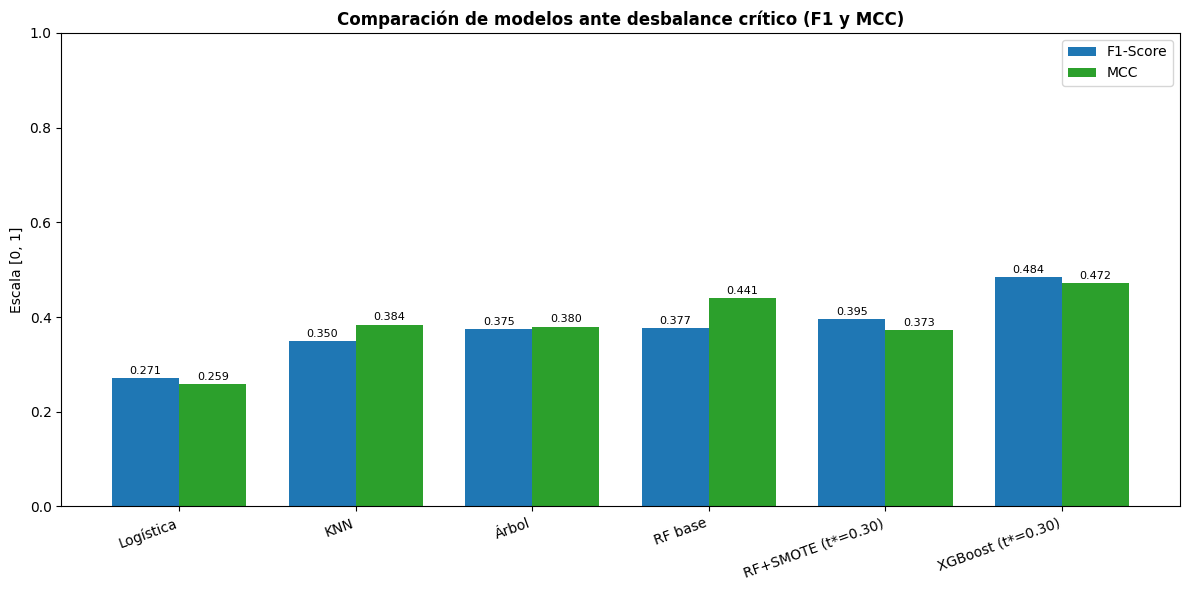

In [ ]:
import matplotlib.pyplot as plt
modelos = list(resultados.keys())
f1s  = [resultados[m]["F1"]  for m in modelos]
mccs = [resultados[m]["MCC"] for m in modelos]

x = np.arange(len(modelos)); width = 0.38
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width/2, f1s,  width, label="F1-Score", color="#1f77b4")
b2 = ax.bar(x + width/2, mccs, width, label="MCC",      color="#2ca02c")
ax.set_title("Comparación de modelos ante desbalance crítico (F1 y MCC)", fontweight="bold")
ax.set_ylabel("Escala [0, 1]"); ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=20, ha="right"); ax.set_ylim(0, 1)
ax.legend()
for bars in (b1, b2):
    for r in bars:
        ax.annotate(f"{r.get_height():.3f}", (r.get_x()+r.get_width()/2, r.get_height()),
                    textcoords="offset points", xytext=(0,3), ha="center", fontsize=8)
plt.tight_layout(); plt.show()

### Evaluación gráfica del modelo RF + SMOTE

Se analizan las predicciones probabilísticas del modelo Random Forest mediante curvas de desempeño y matriz de confusión.

La curva ROC permite evaluar la capacidad del modelo para separar ambas clases mediante diferentes umbrales de decisión, mientras que la curva Precisión–Recall es más representativa en escenarios con fuerte desbalance de clases.

Finalmente, la matriz de confusión muestra los aciertos y errores del modelo utilizando el umbral óptimo seleccionado durante la calibración.

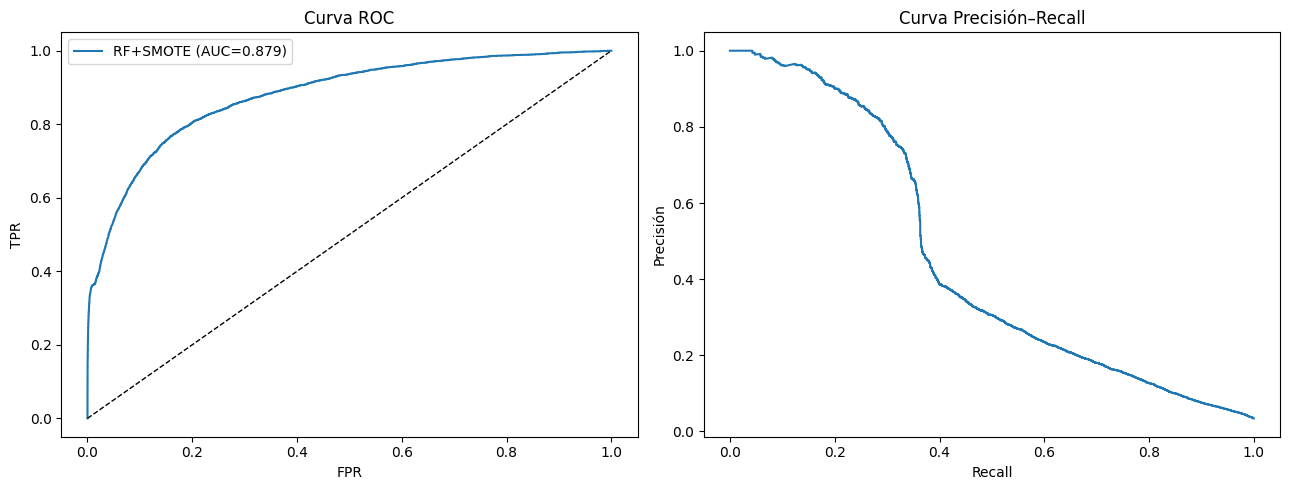

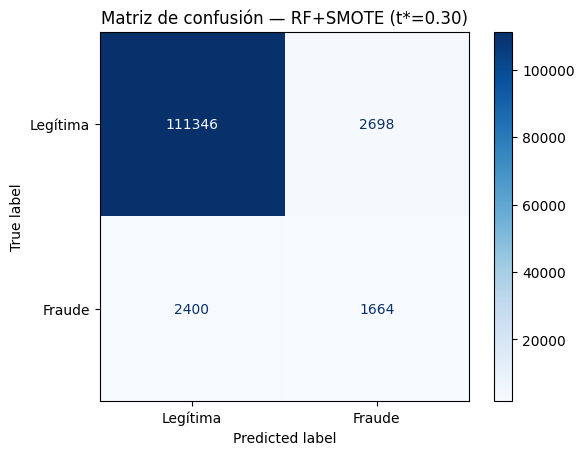

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt, numpy as np

# ROC + Precisión-Recall (RF+SMOTE)
fig,ax=plt.subplots(1,2,figsize=(13,5))
fpr,tpr,_=roc_curve(y_test,prob_rf_test); ax[0].plot(fpr,tpr,label=f"RF+SMOTE (AUC={auc(fpr,tpr):.3f})")
ax[0].plot([0,1],[0,1],"k--",lw=1); ax[0].set_title("Curva ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
pr,rc,_=precision_recall_curve(y_test,prob_rf_test); ax[1].plot(rc,pr)
ax[1].set_title("Curva Precisión–Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precisión")
plt.tight_layout(); plt.show()

# Matriz de confusión (RF+SMOTE en t*)
cm=confusion_matrix(y_test,(prob_rf_test>=t_rf).astype(int))
ConfusionMatrixDisplay(cm,display_labels=["Legítima","Fraude"]).plot(cmap="Blues",values_format="d")
plt.title(f"Matriz de confusión — RF+SMOTE (t*={t_rf:.2f})"); plt.show()

### Comparación final de modelos ensamble

Se comparan las predicciones probabilísticas de Random Forest y XGBoost mediante curvas ROC y Precisión–Recall, permitiendo evaluar su capacidad de separación entre transacciones legítimas y fraudulentas.

Posteriormente, se analiza la matriz de confusión del modelo con mejor desempeño (XGBoost) utilizando el umbral óptimo obtenido durante la calibración.

Este análisis permite cuantificar los aciertos y errores finales del clasificador mediante verdaderos positivos, falsos positivos, falsos negativos y verdaderos negativos.

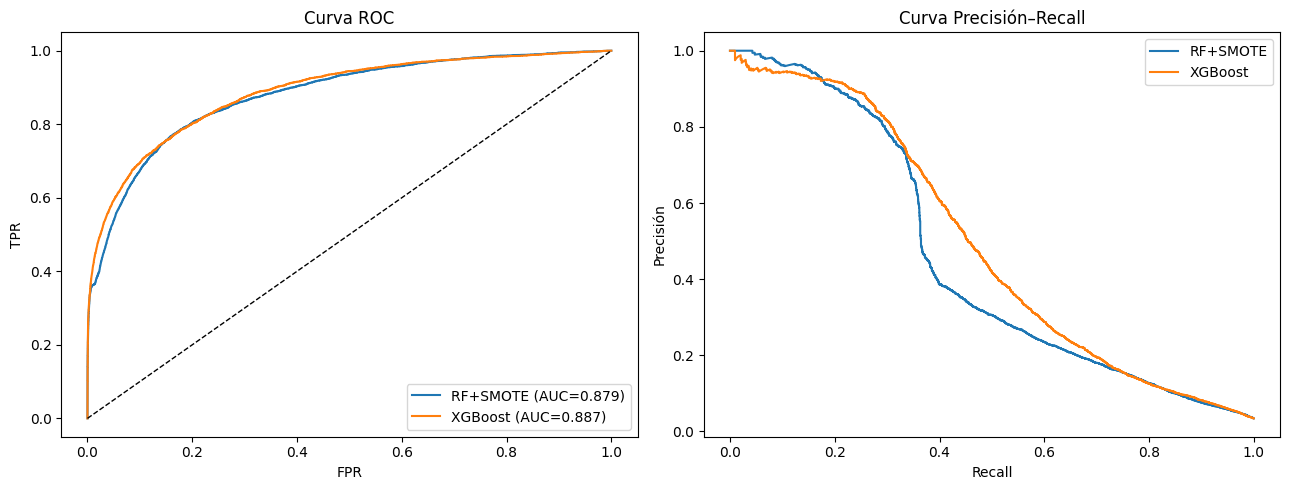

<Figure size 500x400 with 0 Axes>

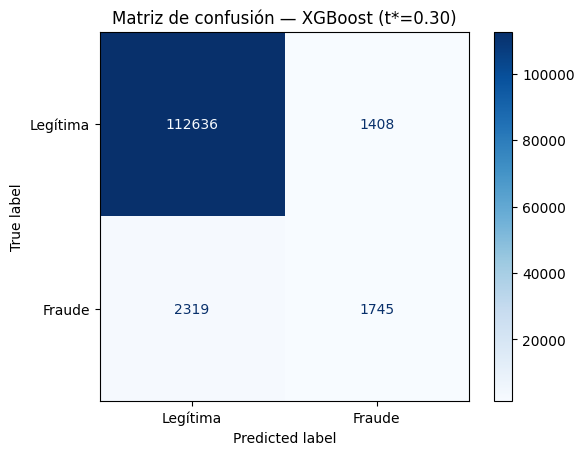

VP: 1745  FP: 1408  FN: 2319  VN: 112636


In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ROC + Precisión-Recall (RF+SMOTE vs XGBoost)
fig, ax = plt.subplots(1, 2, figsize=(13,5))
for nombre, prob in [("RF+SMOTE", prob_rf_test), ("XGBoost", prob_xgb_test)]:
    fpr,tpr,_ = roc_curve(y_test, prob); ax[0].plot(fpr,tpr,label=f"{nombre} (AUC={auc(fpr,tpr):.3f})")
    pr,rc,_   = precision_recall_curve(y_test, prob); ax[1].plot(rc,pr,label=nombre)
ax[0].plot([0,1],[0,1],"k--",lw=1); ax[0].set_title("Curva ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].set_title("Curva Precisión–Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precisión"); ax[1].legend()
plt.tight_layout(); plt.show()

# Matriz de confusión del modelo estrella (XGBoost en t*)
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, (prob_xgb_test >= t_xgb).astype(int))
ConfusionMatrixDisplay(cm, display_labels=["Legítima","Fraude"]).plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusión — XGBoost (t*={t_xgb:.2f})"); plt.show()
print("VP:",cm[1,1]," FP:",cm[0,1]," FN:",cm[1,0]," VN:",cm[0,0])

## Conclusiones

1. **Optimización numérica.**  
La regresión logística permitió aplicar técnicas de optimización iterativa mediante descenso de gradiente, analizando la convergencia de la función de costo. Además, se aplicaron modelos avanzados como XGBoost basados en optimización por gradiente y se calibró el umbral de decisión mediante búsqueda numérica para maximizar el desempeño del clasificador.

2. **Álgebra lineal y reducción dimensional.**  
El análisis PCA permitió transformar el espacio original mediante técnicas matriciales basadas en SVD, reduciendo la redundancia entre variables y conservando la mayor cantidad de información mediante componentes principales.

3. **Metodología y prevención de errores numéricos.**  
La separación temporal de los datos en entrenamiento, validación y prueba, junto con el escalado y ajuste de parámetros únicamente con datos de entrenamiento, permitió evitar fuga de información y obtener evaluaciones más confiables.

4. **Resultados del modelo.**  
Los modelos de ensamble como Random Forest y XGBoost mostraron mejor capacidad para detectar patrones complejos de fraude frente a modelos lineales, especialmente al incorporar técnicas de balanceo como SMOTE y calibración del umbral utilizando métricas adecuadas para datos desbalanceados como F1-Score y MCC.

**Trabajo futuro:**  
Como mejoras futuras se plantea incorporar validación temporal continua (*walk-forward*), calibración de probabilidades y estrategias basadas en costos para priorizar los fraudes según su impacto económico.